# Retail Analytics & AI-Powered Sales Forecasting System

**Name:** Veeralakshmi Gunti

**Project:** Retail Analytics & AI-Powered Sales Forecasting System

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Statsmodels
- Streamlit
- Jupyter Notebook

## Step 1 — Data Loading, Cleaning & Exploratory Data Analysis

This notebook prepares the retail dataset for the later store-segmentation, forecasting, and dashboard stages.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [ ]:
import pandas as pd
import glob
import os

files = glob.glob('/content/*.xlsx')

print("Excel files found:")
for file in files:
    print(file)

FILE_PATH = files[0]

df = pd.read_excel(FILE_PATH)

print("\nDataset shape:", df.shape)
display(df.head())

Excel files found:
/content/4877028-Retail_Sales_Data.xlsx

Dataset shape: (73000, 19)


,Date,Store_ID,Store_Location,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Units_Sold,Total_Sales,Discount_Percentage,Revenue,Customer_Type,Payment_Mode,Promotion_Applied,Stock_On_Hand,Store_Rating,Region,Holiday_Flag
0,13-04-2023,STR_104,Chennai,PRD_072,Sports,Athletics,Reebok,"29,973.06",39,"1,168,949.34",5,"1,110,501.87",Returning,Debit Card,Yes,422,4.40,South,0
1,25-10-2024,STR_103,Delhi,PRD_492,Sports,Outdoor,Yonex,"46,933.78",2,"93,867.56",15,"79,787.43",Returning,UPI,No,302,4.10,North,0
2,28-02-2023,STR_107,Kolkata,PRD_958,Groceries,Household,Nestle,"39,280.28",44,"1,728,332.32",15,"1,469,082.47",Returning,Cash,No,184,3.80,East,0
3,16-06-2023,STR_102,Bangalore,PRD_014,Home Appliances,Kitchen,Whirlpool,"40,439.03",9,"363,951.27",5,"345,753.71",New,UPI,Yes,493,3.70,South,0
4,23-05-2024,STR_108,Ahmedabad,PRD_932,Fashion,Women Clothing,Puma,"9,193.58",4,"36,774.32",5,"34,935.60",Returning,Credit Card,No,359,3.50,West,0


## 1. Dataset Structure & Quality Checks

In [ ]:
print('Columns:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes.to_frame('Data Type'))

print('\nMissing values:')
display(df.isna().sum().to_frame('Missing Values'))

print('\nDuplicate rows:', df.duplicated().sum())

Columns:
['Date', 'Store_ID', 'Store_Location', 'Product_ID', 'Product_Category', 'Product_Subcategory', 'Brand', 'Unit_Price', 'Units_Sold', 'Total_Sales', 'Discount_Percentage', 'Revenue', 'Customer_Type', 'Payment_Mode', 'Promotion_Applied', 'Stock_On_Hand', 'Store_Rating', 'Region', 'Holiday_Flag']

Data types:


,Data Type
Date,object
Store_ID,object
Store_Location,object
Product_ID,object
Product_Category,object
Product_Subcategory,object
Brand,object
Unit_Price,float64
Units_Sold,int64
Total_Sales,float64



Missing values:


,Missing Values
Date,0
Store_ID,0
Store_Location,0
Product_ID,0
Product_Category,0
Product_Subcategory,0
Brand,0
Unit_Price,0
Units_Sold,0
Total_Sales,0



Duplicate rows: 0


In [ ]:
# Convert Date correctly
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

print("Invalid dates:", df['Date'].isna().sum())
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())

Invalid dates: 0
Date range: 2023-01-01 to 2024-12-31


## 2. Feature Engineering

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.quarter
df['Day_Name'] = df['Date'].dt.day_name()
df['Year_Month'] = df['Date'].dt.to_period('M').astype(str)

display(df.head())

,Date,Store_ID,Store_Location,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Units_Sold,Total_Sales,Discount_Percentage,Revenue,Customer_Type,Payment_Mode,Promotion_Applied,Stock_On_Hand,Store_Rating,Region,Holiday_Flag,Year,Month,Month_Name,Quarter,Day_Name,Year_Month
0,2023-04-13,STR_104,Chennai,PRD_072,Sports,Athletics,Reebok,"29,973.06",39,"1,168,949.34",5,"1,110,501.87",Returning,Debit Card,Yes,422,4.40,South,0,2023,4,April,2,Thursday,2023-04
1,2024-10-25,STR_103,Delhi,PRD_492,Sports,Outdoor,Yonex,"46,933.78",2,"93,867.56",15,"79,787.43",Returning,UPI,No,302,4.10,North,0,2024,10,October,4,Friday,2024-10
2,2023-02-28,STR_107,Kolkata,PRD_958,Groceries,Household,Nestle,"39,280.28",44,"1,728,332.32",15,"1,469,082.47",Returning,Cash,No,184,3.80,East,0,2023,2,February,1,Tuesday,2023-02
3,2023-06-16,STR_102,Bangalore,PRD_014,Home Appliances,Kitchen,Whirlpool,"40,439.03",9,"363,951.27",5,"345,753.71",New,UPI,Yes,493,3.70,South,0,2023,6,June,2,Friday,2023-06
4,2024-05-23,STR_108,Ahmedabad,PRD_932,Fashion,Women Clothing,Puma,"9,193.58",4,"36,774.32",5,"34,935.60",Returning,Credit Card,No,359,3.50,West,0,2024,5,May,2,Thursday,2024-05


## 3. Key Dataset Statistics

In [ ]:
print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())
print('Number of stores:', df['Store_ID'].nunique())
print('Number of products:', df['Product_ID'].nunique())
print('Categories:', df['Product_Category'].nunique())
print('Subcategories:', df['Product_Subcategory'].nunique())
print('Brands:', df['Brand'].nunique())
print('Regions:', df['Region'].nunique())

Date range: 2023-01-01 to 2024-12-31
Number of stores: 8
Number of products: 998
Categories: 5
Subcategories: 15
Brands: 20
Regions: 4


## 4. Overall Business KPIs

In [ ]:
kpis = {
    'Total Records': len(df),
    'Total Revenue': df['Revenue'].sum(),
    'Total Sales': df['Total_Sales'].sum(),
    'Total Units Sold': df['Units_Sold'].sum(),
    'Average Revenue / Record': df['Revenue'].mean(),
    'Average Store Rating': df['Store_Rating'].mean()
}

display(pd.DataFrame(kpis.items(), columns=['KPI', 'Value']))

,KPI,Value
0,Total Records,"73,000.00"
1,Total Revenue,"41,133,782,865.04"
2,Total Sales,"45,708,091,467.57"
3,Total Units Sold,"1,817,305.00"
4,Average Revenue / Record,"563,476.48"
5,Average Store Rating,4.25


## 5. Monthly Revenue Trend

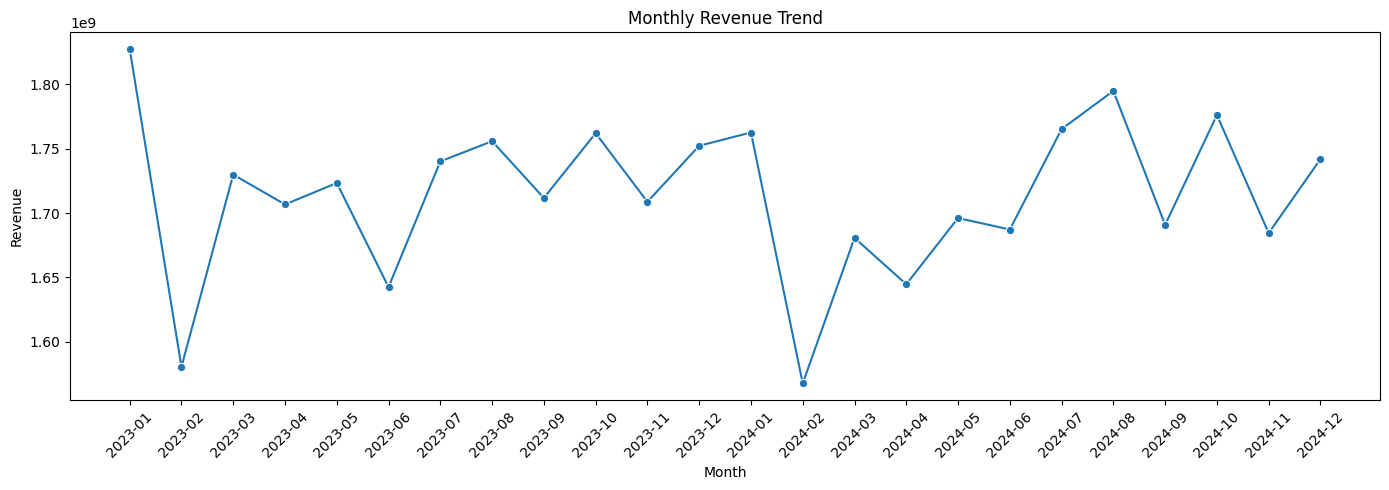

In [ ]:
monthly_revenue = df.groupby('Year_Month', as_index=False)['Revenue'].sum()

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_revenue, x='Year_Month', y='Revenue', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Revenue by Product Category

,Product_Category,Revenue
0,Electronics,"8,318,538,868.88"
3,Home Appliances,"8,262,751,184.02"
1,Fashion,"8,215,645,302.68"
2,Groceries,"8,170,528,429.92"
4,Sports,"8,166,319,079.53"


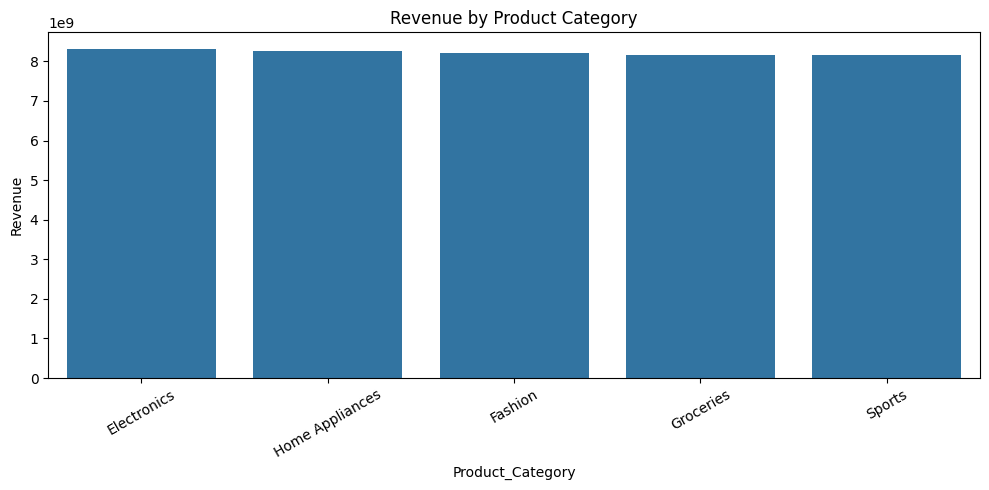

In [ ]:
category_revenue = (df.groupby('Product_Category', as_index=False)['Revenue']
                    .sum()
                    .sort_values('Revenue', ascending=False))

display(category_revenue)

plt.figure(figsize=(10, 5))
sns.barplot(data=category_revenue, x='Product_Category', y='Revenue')
plt.title('Revenue by Product Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Store Performance

In [ ]:
store_performance = (df.groupby('Store_ID')
                     .agg(Total_Revenue=('Revenue', 'sum'),
                          Total_Sales=('Total_Sales', 'sum'),
                          Units_Sold=('Units_Sold', 'sum'),
                          Avg_Discount=('Discount_Percentage', 'mean'),
                          Avg_Stock=('Stock_On_Hand', 'mean'),
                          Avg_Rating=('Store_Rating', 'mean'),
                          Transactions=('Product_ID', 'count'))
                     .sort_values('Total_Revenue', ascending=False))

display(store_performance)

,Total_Revenue,Total_Sales,Units_Sold,Avg_Discount,Avg_Stock,Avg_Rating,Transactions
Store_ID,,,,,,,
STR_103,"5,223,064,263.84","5,803,046,637.11",229475,9.97,275.59,4.25,9173
STR_102,"5,186,276,605.87","5,758,117,039.56",228384,10.00,277.11,4.25,9174
STR_101,"5,169,675,266.91","5,751,483,597.78",226670,10.09,274.84,4.25,9039
STR_104,"5,165,937,477.75","5,749,821,347.88",228580,10.11,273.57,4.25,9186
STR_105,"5,161,898,681.92","5,737,160,207.60",227715,10.08,273.83,4.25,9254
STR_107,"5,107,832,301.73","5,672,850,014.33",229403,9.95,275.84,4.25,9136
STR_108,"5,078,321,969.54","5,634,169,569.91",223994,9.94,272.99,4.25,9024
STR_106,"5,040,776,297.48","5,601,443,053.40",223084,9.94,273.20,4.25,9014


## 8. Promotion vs Non-Promotion Analysis

In [ ]:
promotion_analysis = (df.groupby('Promotion_Applied')
                       .agg(Revenue=('Revenue', 'sum'),
                            Units_Sold=('Units_Sold', 'sum'),
                            Avg_Discount=('Discount_Percentage', 'mean'),
                            Transactions=('Product_ID', 'count'))
                       .reset_index())
display(promotion_analysis)

,Promotion_Applied,Revenue,Units_Sold,Avg_Discount,Transactions
0,No,"28,847,458,517.64",1273679,9.98,51151
1,Yes,"12,286,324,347.40",543626,10.08,21849


## 9. Holiday vs Non-Holiday Analysis

In [ ]:
holiday_analysis = (df.groupby('Holiday_Flag')
                    .agg(Revenue=('Revenue', 'sum'),
                         Units_Sold=('Units_Sold', 'sum'),
                         Transactions=('Product_ID', 'count'))
                    .reset_index())
display(holiday_analysis)

,Holiday_Flag,Revenue,Units_Sold,Transactions
0,0,"40,640,914,750.14",1795915,72103
1,1,"492,868,114.90",21390,897


## 10. Customer Type Analysis

In [ ]:
customer_analysis = (df.groupby('Customer_Type')
                      .agg(Revenue=('Revenue', 'sum'),
                           Units_Sold=('Units_Sold', 'sum'),
                           Transactions=('Product_ID', 'count'))
                      .reset_index()
                      .sort_values('Revenue', ascending=False))
display(customer_analysis)

,Customer_Type,Revenue,Units_Sold,Transactions
1,Returning,"24,640,154,811.88",1092135,43782
0,New,"16,493,628,053.16",725170,29218


## Step 1 Output

After running this notebook, record the actual findings for the final report:
- Overall revenue and sales
- Best and worst months
- Best product category
- Best and worst stores
- Promotion impact
- Holiday impact
- Customer-type contribution

**Important:** Do not write business conclusions until the notebook has produced the actual values.

# Step 2 — Advanced Exploratory Data Analysis

In [ ]:
# ==========================================
# STEP 2 — ADVANCED EDA
# ==========================================

print("========== ADVANCED EDA ==========")

========== ADVANCED EDA ==========


##2. Year-over-Year Revenue Analysis

In [ ]:
# Year-wise Revenue Analysis

yearly_revenue = (
    df.groupby('Year')
      .agg(
          Revenue=('Revenue', 'sum'),
          Total_Sales=('Total_Sales', 'sum'),
          Units_Sold=('Units_Sold', 'sum')
      )
      .reset_index()
)

display(yearly_revenue)

# Calculate YoY Growth
yearly_revenue['Revenue_Growth_%'] = (
    yearly_revenue['Revenue'].pct_change() * 100
)

display(yearly_revenue)

,Year,Revenue,Total_Sales,Units_Sold
0,2023,"20,641,105,508.52","22,926,576,747.29",910315
1,2024,"20,492,677,356.53","22,781,514,720.28",906990


,Year,Revenue,Total_Sales,Units_Sold,Revenue_Growth_%
0,2023,"20,641,105,508.52","22,926,576,747.29",910315,NaN
1,2024,"20,492,677,356.53","22,781,514,720.28",906990,-0.72


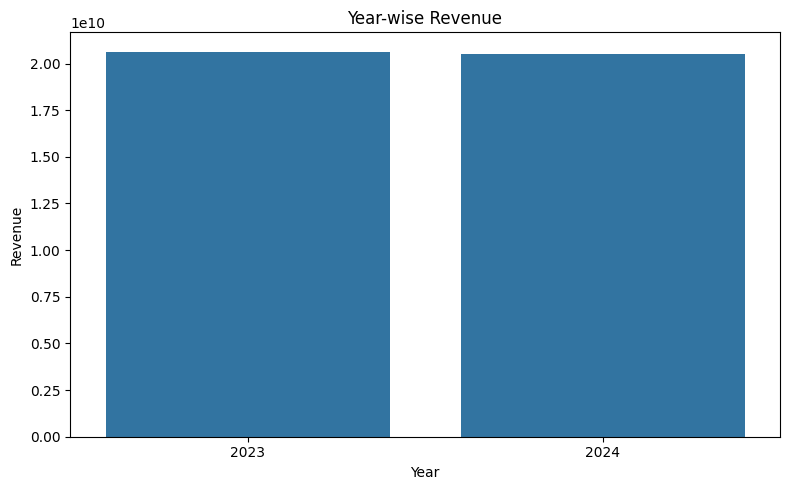

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=yearly_revenue,
    x='Year',
    y='Revenue'
)

plt.title('Year-wise Revenue')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

##3. Monthly Seasonality

In [ ]:
monthly_seasonality = (
    df.groupby('Month')
      .agg(
          Revenue=('Revenue', 'sum'),
          Units_Sold=('Units_Sold', 'sum')
      )
      .reset_index()
)

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_seasonality['Month_Name'] = (
    pd.to_datetime(
        monthly_seasonality['Month'],
        format='%m'
    ).dt.month_name()
)

display(monthly_seasonality)

,Month,Revenue,Units_Sold,Month_Name
0,1,"3,589,902,642.51",156859,January
1,2,"3,148,417,418.55",139825,February
2,3,"3,410,626,721.40",151124,March
3,4,"3,351,443,726.06",150204,April
4,5,"3,419,507,922.05",152729,May
5,6,"3,329,776,747.49",147803,June
6,7,"3,505,301,171.24",154146,July
7,8,"3,550,667,753.47",156524,August
8,9,"3,402,626,723.13",150834,September
9,10,"3,538,155,975.83",155481,October


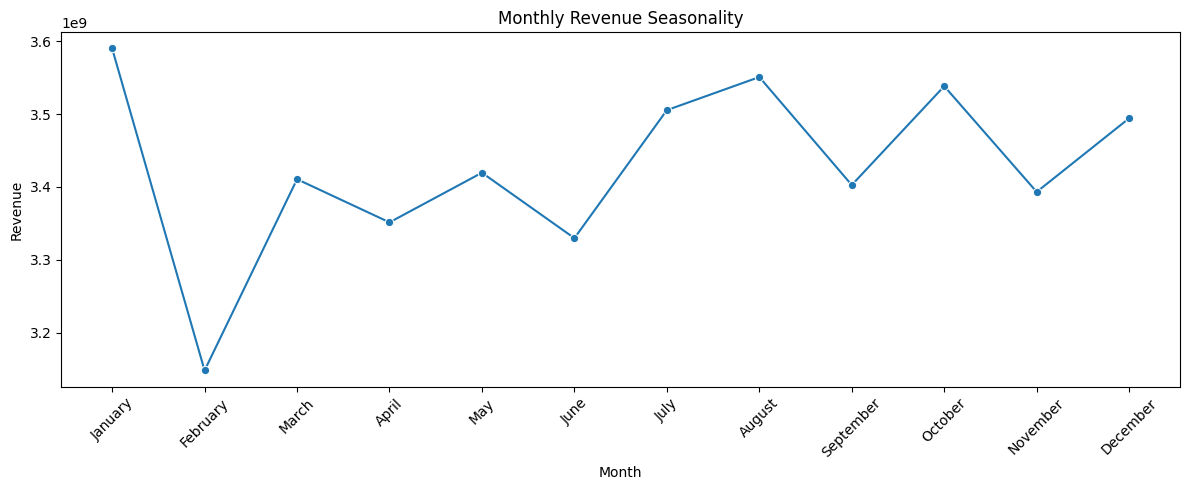

In [ ]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_seasonality,
    x='Month_Name',
    y='Revenue',
    marker='o'
)

plt.title('Monthly Revenue Seasonality')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##4. Regional Performance

In [ ]:
region_analysis = (
    df.groupby('Region')
      .agg(
          Revenue=('Revenue', 'sum'),
          Total_Sales=('Total_Sales', 'sum'),
          Units_Sold=('Units_Sold', 'sum'),
          Transactions=('Product_ID', 'count'),
          Avg_Rating=('Store_Rating', 'mean')
      )
      .sort_values('Revenue', ascending=False)
)

display(region_analysis)

,Revenue,Total_Sales,Units_Sold,Transactions,Avg_Rating
Region,,,,,
West,"15,409,895,918.38","17,122,813,375.29",678379,27317,4.25
South,"15,392,990,381.10","17,109,381,440.84",680048,27374,4.25
North,"5,223,064,263.84","5,803,046,637.11",229475,9173,4.25
East,"5,107,832,301.73","5,672,850,014.33",229403,9136,4.25


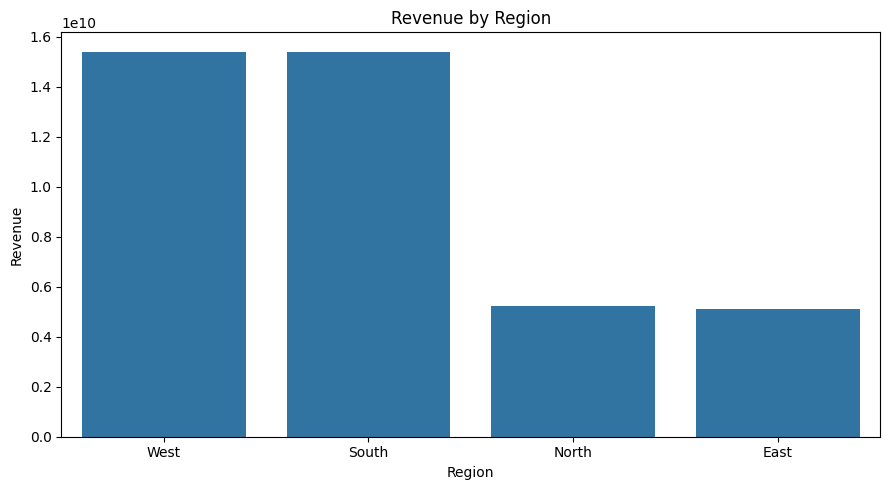

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=region_analysis.reset_index(),
    x='Region',
    y='Revenue'
)

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

##5. Top 10 Brands

In [ ]:
top_brands = (
    df.groupby('Brand')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

display(top_brands)

,Brand,Revenue
0,Levis,"2,136,318,689.50"
1,Amul,"2,108,331,686.06"
2,OnePlus,"2,091,627,146.66"
3,Samsung,"2,086,056,841.32"
4,LG,"2,084,596,712.93"
5,Sony,"2,081,671,657.03"
6,Philips,"2,080,068,566.71"
7,Prestige,"2,062,600,707.83"
8,Apple,"2,059,183,223.87"
9,Adidas,"2,058,839,125.78"


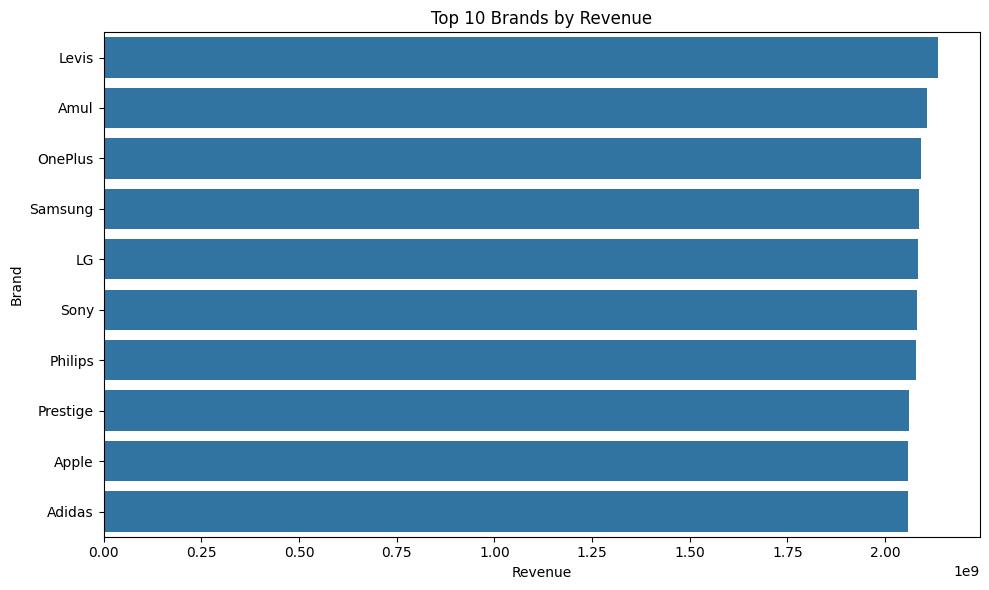

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_brands,
    x='Revenue',
    y='Brand'
)

plt.title('Top 10 Brands by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

##6. Top 10 Products

In [ ]:
top_products = (
    df.groupby('Product_ID')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

display(top_products)

,Product_ID,Revenue
0,PRD_713,"67,829,760.43"
1,PRD_379,"67,512,418.96"
2,PRD_632,"62,616,932.40"
3,PRD_279,"59,870,015.07"
4,PRD_727,"58,192,889.08"
5,PRD_602,"57,787,855.45"
6,PRD_197,"57,329,473.53"
7,PRD_333,"56,596,982.71"
8,PRD_041,"56,322,986.34"
9,PRD_145,"56,158,798.09"


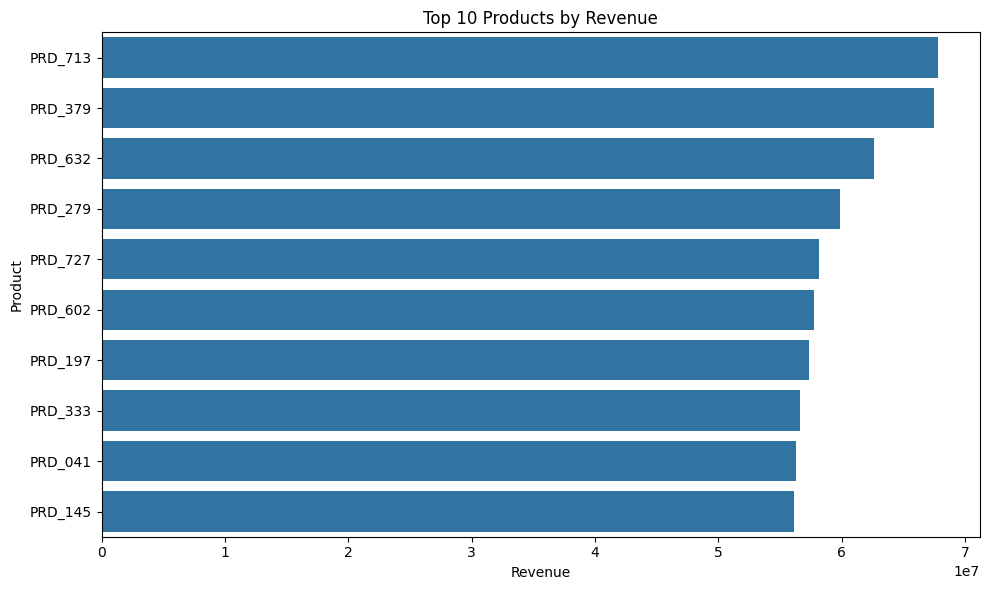

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_products,
    x='Revenue',
    y='Product_ID'
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

##7. Discount vs Revenue

In [ ]:
discount_analysis = (
    df.groupby('Discount_Percentage')
      .agg(
          Revenue=('Revenue', 'sum'),
          Units_Sold=('Units_Sold', 'sum'),
          Transactions=('Product_ID', 'count')
      )
      .reset_index()
      .sort_values('Discount_Percentage')
)

display(discount_analysis)

,Discount_Percentage,Revenue,Units_Sold,Transactions
0,0,"9,142,696,563.32",362684,14560
1,5,"8,618,498,480.18",362478,14556
2,10,"8,219,566,240.69",362443,14600
3,15,"7,899,384,741.92",368983,14740
4,20,"7,253,636,838.93",360717,14544


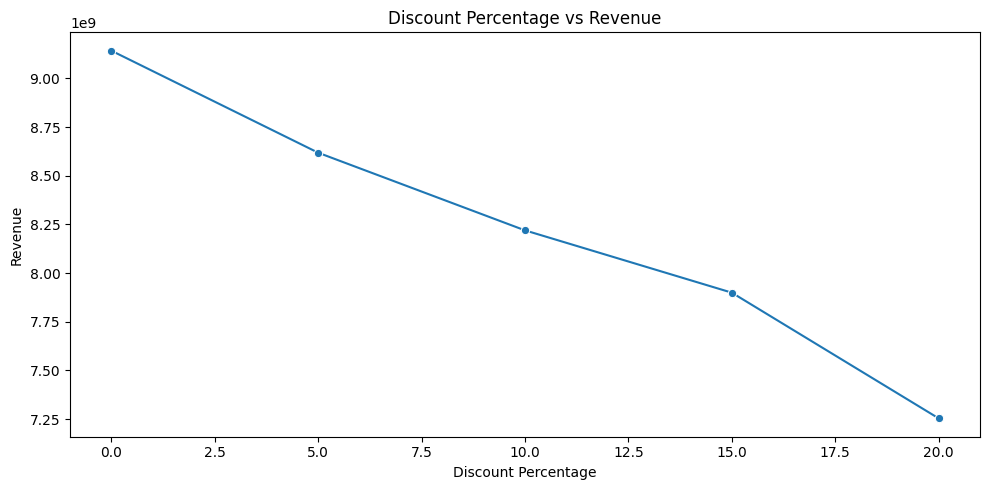

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=discount_analysis,
    x='Discount_Percentage',
    y='Revenue',
    marker='o'
)

plt.title('Discount Percentage vs Revenue')
plt.xlabel('Discount Percentage')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

##8. Promotion Effectiveness

In [ ]:
promotion_effectiveness = (
    df.groupby('Promotion_Applied')
      .agg(
          Revenue=('Revenue', 'sum'),
          Units_Sold=('Units_Sold', 'sum'),
          Transactions=('Product_ID', 'count'),
          Avg_Discount=('Discount_Percentage', 'mean')
      )
)

promotion_effectiveness['Revenue_per_Transaction'] = (
    promotion_effectiveness['Revenue'] /
    promotion_effectiveness['Transactions']
)

promotion_effectiveness['Units_per_Transaction'] = (
    promotion_effectiveness['Units_Sold'] /
    promotion_effectiveness['Transactions']
)

display(promotion_effectiveness)

,Revenue,Units_Sold,Transactions,Avg_Discount,Revenue_per_Transaction,Units_per_Transaction
Promotion_Applied,,,,,,
No,"28,847,458,517.64",1273679,51151,9.98,"563,966.66",24.90
Yes,"12,286,324,347.40",543626,21849,10.08,"562,328.91",24.88


##9. Category × Year Analysis

In [ ]:
category_year = (
    df.groupby(['Year', 'Product_Category'])['Revenue']
      .sum()
      .reset_index()
)

display(category_year)

,Year,Product_Category,Revenue
0,2023,Electronics,"4,216,909,770.70"
1,2023,Fashion,"4,120,718,105.45"
2,2023,Groceries,"4,054,586,727.40"
3,2023,Home Appliances,"4,167,402,141.20"
4,2023,Sports,"4,081,488,763.76"
5,2024,Electronics,"4,101,629,098.18"
6,2024,Fashion,"4,094,927,197.23"
7,2024,Groceries,"4,115,941,702.52"
8,2024,Home Appliances,"4,095,349,042.83"
9,2024,Sports,"4,084,830,315.77"


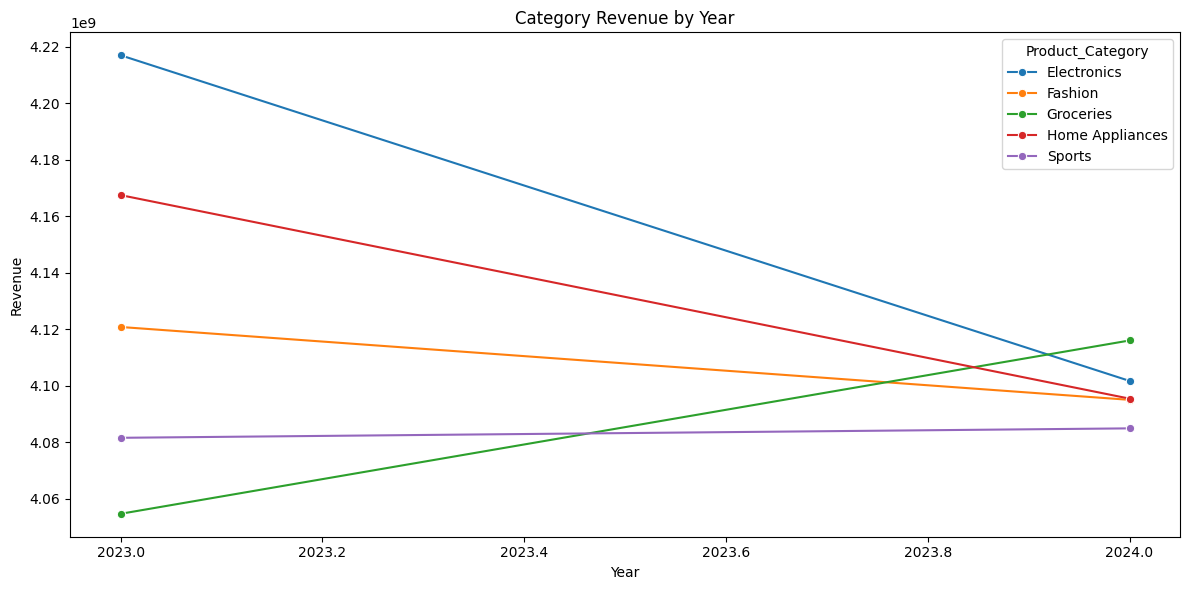

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=category_year,
    x='Year',
    y='Revenue',
    hue='Product_Category',
    marker='o'
)

plt.title('Category Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

##10. Store × Region Performance

In [ ]:
store_region = (
    df.groupby(['Store_ID', 'Store_Location', 'Region'])
      .agg(
          Revenue=('Revenue', 'sum'),
          Units_Sold=('Units_Sold', 'sum'),
          Avg_Rating=('Store_Rating', 'mean')
      )
      .sort_values('Revenue', ascending=False)
)

display(store_region)

,,,Revenue,Units_Sold,Avg_Rating
Store_ID,Store_Location,Region,,,
STR_103,Delhi,North,"5,223,064,263.84",229475,4.25
STR_102,Bangalore,South,"5,186,276,605.87",228384,4.25
STR_101,Mumbai,West,"5,169,675,266.91",226670,4.25
STR_104,Chennai,South,"5,165,937,477.75",228580,4.25
STR_105,Pune,West,"5,161,898,681.92",227715,4.25
STR_107,Kolkata,East,"5,107,832,301.73",229403,4.25
STR_108,Ahmedabad,West,"5,078,321,969.54",223994,4.25
STR_106,Hyderabad,South,"5,040,776,297.48",223084,4.25


## Step 2 — Key Areas Identified

The advanced EDA evaluates:

- Year-over-year revenue performance
- Monthly and seasonal revenue patterns
- Regional performance
- Top-performing brands
- Top-performing products
- Discount and revenue relationship
- Promotion effectiveness
- Category performance across years
- Store and regional performance

These findings will be used as inputs for the next stages:
1. Store Segmentation
2. Sales Forecasting
3. AI-Powered Business Insights
4. Interactive Dashboard

# Step 3 — Store Segmentation Using K-Means Clustering

In [ ]:
# ==========================================
# STEP 3.1 — STORE-LEVEL DATASET
# ==========================================

store_features = (
    df.groupby(['Store_ID', 'Store_Location', 'Region'])
      .agg(
          Total_Revenue=('Revenue', 'sum'),
          Total_Units_Sold=('Units_Sold', 'sum'),
          Total_Transactions=('Product_ID', 'count'),
          Avg_Discount=('Discount_Percentage', 'mean'),
          Avg_Stock=('Stock_On_Hand', 'mean'),
          Avg_Rating=('Store_Rating', 'mean')
      )
      .reset_index()
)

display(store_features)

,Store_ID,Store_Location,Region,Total_Revenue,Total_Units_Sold,Total_Transactions,Avg_Discount,Avg_Stock,Avg_Rating
0,STR_101,Mumbai,West,"5,169,675,266.91",226670,9039,10.09,274.84,4.25
1,STR_102,Bangalore,South,"5,186,276,605.87",228384,9174,10.00,277.11,4.25
2,STR_103,Delhi,North,"5,223,064,263.84",229475,9173,9.97,275.59,4.25
3,STR_104,Chennai,South,"5,165,937,477.75",228580,9186,10.11,273.57,4.25
4,STR_105,Pune,West,"5,161,898,681.92",227715,9254,10.08,273.83,4.25
5,STR_106,Hyderabad,South,"5,040,776,297.48",223084,9014,9.94,273.20,4.25
6,STR_107,Kolkata,East,"5,107,832,301.73",229403,9136,9.95,275.84,4.25
7,STR_108,Ahmedabad,West,"5,078,321,969.54",223994,9024,9.94,272.99,4.25


##3.2 — Select ML Features

In [ ]:
# Features used for K-Means clustering

features = [
    'Total_Revenue',
    'Total_Units_Sold',
    'Total_Transactions',
    'Avg_Discount',
    'Avg_Stock',
    'Avg_Rating'
]

X = store_features[features].copy()

display(X)

,Total_Revenue,Total_Units_Sold,Total_Transactions,Avg_Discount,Avg_Stock,Avg_Rating
0,"5,169,675,266.91",226670,9039,10.09,274.84,4.25
1,"5,186,276,605.87",228384,9174,10.00,277.11,4.25
2,"5,223,064,263.84",229475,9173,9.97,275.59,4.25
3,"5,165,937,477.75",228580,9186,10.11,273.57,4.25
4,"5,161,898,681.92",227715,9254,10.08,273.83,4.25
5,"5,040,776,297.48",223084,9014,9.94,273.20,4.25
6,"5,107,832,301.73",229403,9136,9.95,275.84,4.25
7,"5,078,321,969.54",223994,9024,9.94,272.99,4.25


##3.3 — Standardize the Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

display(X_scaled)

,Total_Revenue,Total_Units_Sold,Total_Transactions,Avg_Discount,Avg_Stock,Avg_Rating
0,0.49,-0.22,-1.04,1.20,0.16,0.44
1,0.79,0.54,0.59,-0.17,1.81,0.90
2,1.43,1.02,0.58,-0.61,0.71,0.75
3,0.43,0.63,0.73,1.52,-0.76,0.62
4,0.36,0.24,1.55,0.98,-0.58,-2.33
5,-1.78,-1.80,-1.34,-0.96,-1.04,0.02
6,-0.60,0.99,0.13,-0.86,0.89,-0.73
7,-1.12,-1.40,-1.22,-1.10,-1.19,0.32


##3.4 — Elbow Method

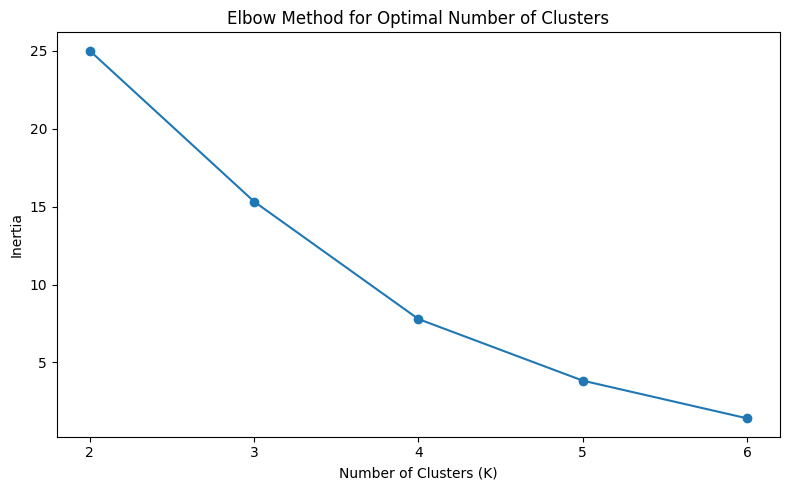

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 7),
    inertia,
    marker='o'
)

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 7))
plt.tight_layout()
plt.show()

##3.5 — Validate K with Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 6):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

print("Silhouette Scores:")

for k, score in silhouette_scores.items():
    print(f"K = {k}: {score:.4f}")

Silhouette Scores:
K = 2: 0.4214
K = 3: 0.3601
K = 4: 0.3750
K = 5: 0.3635


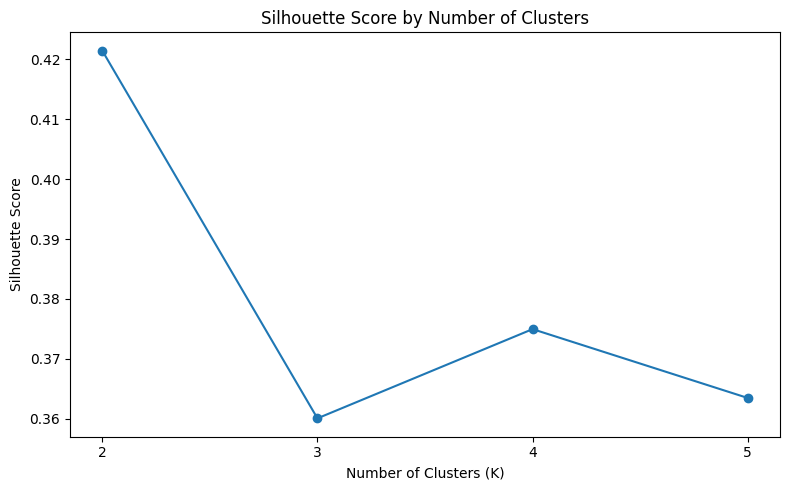

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker='o'
)

plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 6))
plt.tight_layout()
plt.show()

##3.6 — Create Final K-Means Clusters

In [ ]:
# ==========================================
# STEP 3.6 — FINAL K-MEANS MODEL
# ==========================================

optimal_k = 2

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

store_features['Cluster'] = kmeans.fit_predict(X_scaled)

display(
    store_features[
        ['Store_ID', 'Store_Location', 'Region', 'Cluster',
         'Total_Revenue', 'Total_Units_Sold',
         'Total_Transactions', 'Avg_Discount',
         'Avg_Stock', 'Avg_Rating']
    ].sort_values('Cluster')
)

,Store_ID,Store_Location,Region,Cluster,Total_Revenue,Total_Units_Sold,Total_Transactions,Avg_Discount,Avg_Stock,Avg_Rating
0,STR_101,Mumbai,West,0,"5,169,675,266.91",226670,9039,10.09,274.84,4.25
1,STR_102,Bangalore,South,0,"5,186,276,605.87",228384,9174,10.00,277.11,4.25
2,STR_103,Delhi,North,0,"5,223,064,263.84",229475,9173,9.97,275.59,4.25
3,STR_104,Chennai,South,0,"5,165,937,477.75",228580,9186,10.11,273.57,4.25
4,STR_105,Pune,West,0,"5,161,898,681.92",227715,9254,10.08,273.83,4.25
6,STR_107,Kolkata,East,0,"5,107,832,301.73",229403,9136,9.95,275.84,4.25
5,STR_106,Hyderabad,South,1,"5,040,776,297.48",223084,9014,9.94,273.20,4.25
7,STR_108,Ahmedabad,West,1,"5,078,321,969.54",223994,9024,9.94,272.99,4.25


In [ ]:
# ==========================================
# STEP 3.7 — CLUSTER PROFILE
# ==========================================

cluster_profile = (
    store_features
    .groupby('Cluster')
    .agg(
        Stores=('Store_ID', 'count'),
        Avg_Revenue=('Total_Revenue', 'mean'),
        Avg_Units_Sold=('Total_Units_Sold', 'mean'),
        Avg_Transactions=('Total_Transactions', 'mean'),
        Avg_Discount=('Avg_Discount', 'mean'),
        Avg_Stock=('Avg_Stock', 'mean'),
        Avg_Rating=('Avg_Rating', 'mean')
    )
    .reset_index()
)

display(cluster_profile)

,Cluster,Stores,Avg_Revenue,Avg_Units_Sold,Avg_Transactions,Avg_Discount,Avg_Stock,Avg_Rating
0,0,6,"5,169,114,099.67","228,371.17","9,160.33",10.03,275.13,4.25
1,1,2,"5,059,549,133.51","223,539.00","9,019.00",9.94,273.10,4.25


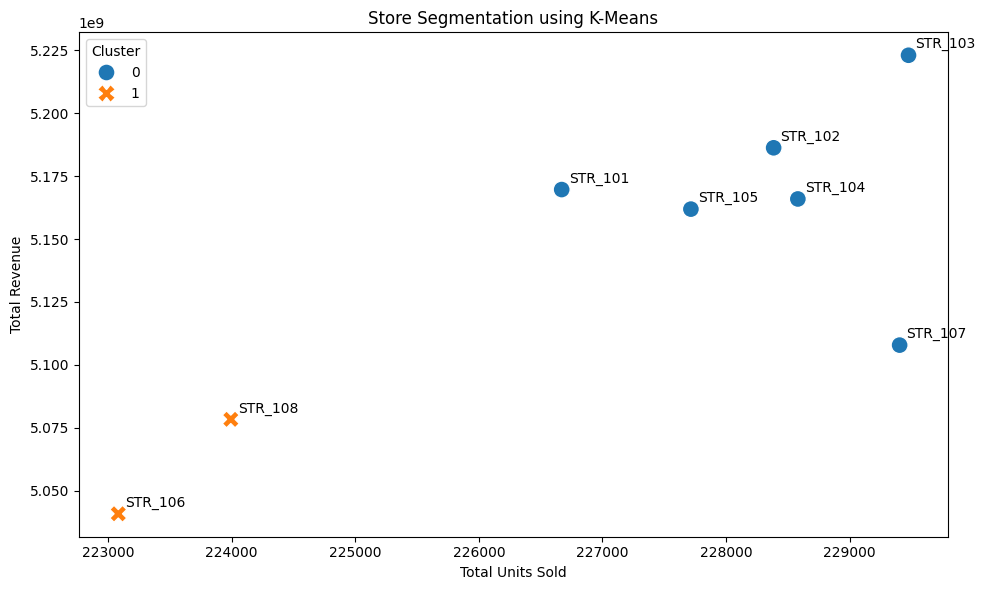

In [ ]:
# ==========================================
# STEP 3.8 — STORE CLUSTER VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=store_features,
    x='Total_Units_Sold',
    y='Total_Revenue',
    hue='Cluster',
    style='Cluster',
    s=150
)

for _, row in store_features.iterrows():
    plt.annotate(
        row['Store_ID'],
        (row['Total_Units_Sold'], row['Total_Revenue']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('Store Segmentation using K-Means')
plt.xlabel('Total Units Sold')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

## Step 3 — Store Segmentation Findings

K-Means clustering was applied to store-level revenue, units sold, transaction volume, discount, stock, and rating features.

The Elbow Method and Silhouette Score were evaluated to determine an appropriate number of clusters. Based on the validation results, K=2 was selected.

Cluster 0 contains six stores with comparatively higher average revenue, units sold, and transaction volume.

Cluster 1 contains two stores with comparatively lower average revenue, units sold, and transaction volume.

These segments can be used to support differentiated store-level business strategies and performance monitoring.

# Step 4 — Sales Forecasting Using Time-Series Analysis

In [ ]:
# ==========================================
# STEP 4.1 — PREPARE MONTHLY REVENUE DATA
# ==========================================

monthly_revenue = (
    df.groupby('Year_Month')['Revenue']
      .sum()
      .reset_index()
)

monthly_revenue['Year_Month'] = pd.to_datetime(
    monthly_revenue['Year_Month']
)

monthly_revenue = monthly_revenue.sort_values('Year_Month')

display(monthly_revenue)

print("Number of months:", len(monthly_revenue))
print(
    "Forecasting period:",
    monthly_revenue['Year_Month'].min().date(),
    "to",
    monthly_revenue['Year_Month'].max().date()
)

,Year_Month,Revenue
0,2023-01-01,"1,827,349,859.16"
1,2023-02-01,"1,580,617,839.23"
2,2023-03-01,"1,729,884,297.82"
3,2023-04-01,"1,706,695,985.24"
4,2023-05-01,"1,723,353,936.88"
5,2023-06-01,"1,642,546,344.18"
6,2023-07-01,"1,740,116,903.20"
7,2023-08-01,"1,755,809,542.68"
8,2023-09-01,"1,711,730,911.71"
9,2023-10-01,"1,762,008,237.74"


Number of months: 24
Forecasting period: 2023-01-01 to 2024-12-01


##4.2 — Visualize the Revenue Trend

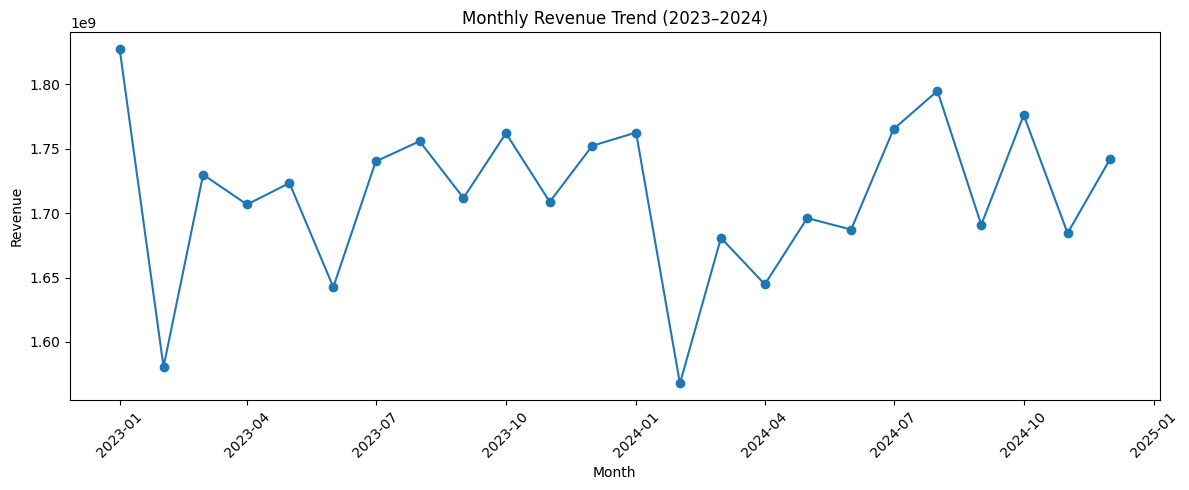

In [ ]:
# ==========================================
# STEP 4.2 — MONTHLY REVENUE TREND
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue['Year_Month'],
    monthly_revenue['Revenue'],
    marker='o'
)

plt.title('Monthly Revenue Trend (2023–2024)')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##4.3 — Create Train/Test Data

In [ ]:
# ==========================================
# STEP 4.3 — TRAIN / TEST SPLIT
# ==========================================

train = monthly_revenue.iloc[:-6].copy()
test = monthly_revenue.iloc[-6:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train['Year_Month'].min().date(), "to", train['Year_Month'].max().date())

print("\nTesting period:")
print(test['Year_Month'].min().date(), "to", test['Year_Month'].max().date())

Training observations: 18
Testing observations: 6

Training period:
2023-01-01 to 2024-06-01

Testing period:
2024-07-01 to 2024-12-01


##4.4 — Train the Forecasting Model

In [ ]:
# ==========================================
# STEP 4.4 — ARIMA FORECASTING MODEL
# ==========================================

from statsmodels.tsa.arima.model import ARIMA

# Create training time series
train_series = train.set_index('Year_Month')['Revenue']

# ARIMA model
model = ARIMA(
    train_series,
    order=(1, 1, 1)
)

fit = model.fit()

# Forecast the 6-month test period
forecast = fit.forecast(steps=len(test))

forecast = pd.Series(
    forecast.values,
    index=test['Year_Month']
)

comparison = pd.DataFrame({
    'Actual_Revenue': test.set_index('Year_Month')['Revenue'],
    'Forecast_Revenue': forecast
})

display(comparison)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Actual_Revenue,Forecast_Revenue
Year_Month,,
2024-07-01,"1,765,184,268.04","1,692,302,452.46"
2024-08-01,"1,794,858,210.79","1,689,903,256.06"
2024-09-01,"1,690,895,811.42","1,691,038,131.37"
2024-10-01,"1,776,147,738.09","1,690,501,309.13"
2024-11-01,"1,684,455,813.73","1,690,755,238.45"
2024-12-01,"1,741,908,598.92","1,690,635,124.02"


## 4.5 — Forecast Model Evaluation

In [ ]:
# ==========================================
# STEP 4.5 — FORECAST MODEL EVALUATION
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = test.set_index('Year_Month')['Revenue']

mae = mean_absolute_error(actual, forecast)

rmse = np.sqrt(
    mean_squared_error(actual, forecast)
)

mape = np.mean(
    np.abs((actual - forecast) / actual)
) * 100

print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : ₹53,533,069.81
RMSE : ₹66,246,112.58
MAPE : 3.02%


## 4.6 — Actual vs Forecast Revenue

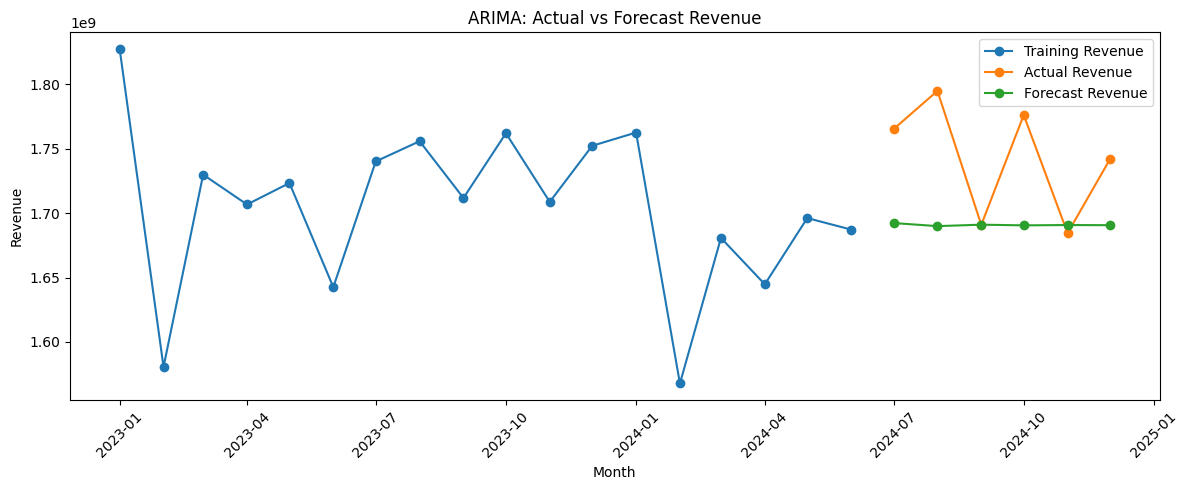

In [ ]:
# ==========================================
# STEP 4.6 — ACTUAL VS FORECAST
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    train['Year_Month'],
    train['Revenue'],
    label='Training Revenue',
    marker='o'
)

plt.plot(
    test['Year_Month'],
    actual,
    label='Actual Revenue',
    marker='o'
)

plt.plot(
    test['Year_Month'],
    forecast,
    label='Forecast Revenue',
    marker='o'
)

plt.title('ARIMA: Actual vs Forecast Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.7 — Future Revenue Forecast

In [ ]:
# ==========================================
# STEP 4.7 — FINAL ARIMA MODEL
# ==========================================

# Use all available historical data
full_series = monthly_revenue.set_index('Year_Month')['Revenue']

# Train final ARIMA model on all 24 months
final_model = ARIMA(
    full_series,
    order=(1, 1, 1)
)

final_fit = final_model.fit()

# Forecast next 6 months
future_forecast = final_fit.forecast(steps=6)

# Create future dates
future_dates = pd.date_range(
    start=full_series.index.max() + pd.offsets.MonthBegin(1),
    periods=6,
    freq='MS'
)

future_forecast = pd.Series(
    future_forecast.values,
    index=future_dates
)

future_forecast_df = pd.DataFrame({
    'Year_Month': future_forecast.index,
    'Forecast_Revenue': future_forecast.values
})

display(future_forecast_df)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Year_Month,Forecast_Revenue
0,2025-01-01,"1,727,750,194.34"
1,2025-02-01,"1,734,336,496.77"
2,2025-03-01,"1,731,272,636.04"
3,2025-04-01,"1,732,697,903.51"
4,2025-05-01,"1,732,034,887.95"
5,2025-06-01,"1,732,343,314.01"


## 4.8 — Future Revenue Forecast Visualization

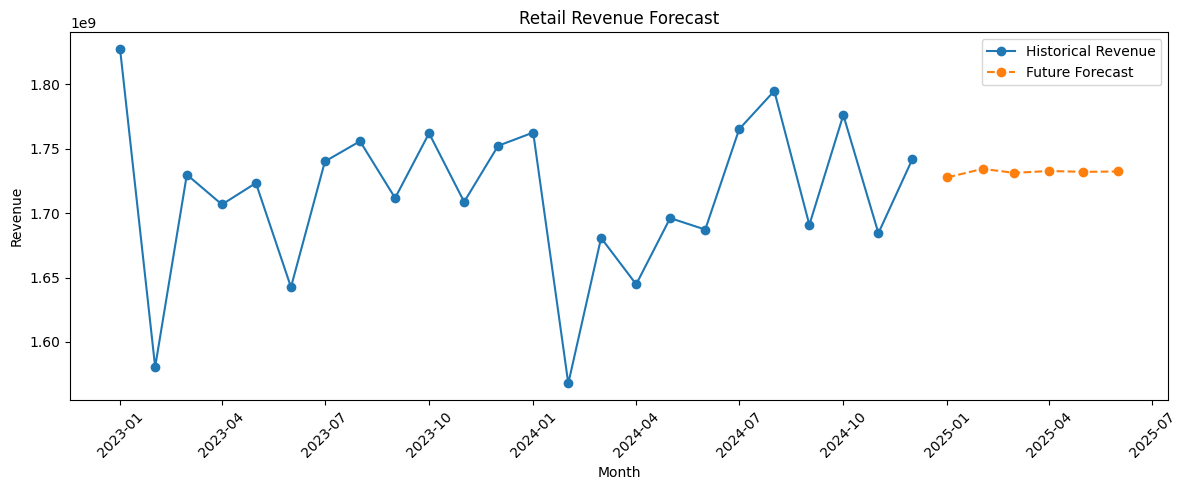

In [ ]:
# ==========================================
# STEP 4.8 — FUTURE REVENUE FORECAST GRAPH
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue['Year_Month'],
    monthly_revenue['Revenue'],
    marker='o',
    label='Historical Revenue'
)

plt.plot(
    future_forecast_df['Year_Month'],
    future_forecast_df['Forecast_Revenue'],
    marker='o',
    linestyle='--',
    label='Future Forecast'
)

plt.title('Retail Revenue Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 4 — Sales Forecasting Findings

An ARIMA (1,1,1) time-series model was developed to forecast monthly retail revenue.

The model was trained using historical revenue data and evaluated on the final six months of the dataset. The model achieved a MAPE of 3.02%, indicating good forecasting accuracy on the test period.

The final model was then trained using the complete 24-month historical dataset and used to forecast revenue for January 2025 to June 2025.

The forecast indicates expected monthly revenue of approximately ₹1.73 billion during the six-month forecast horizon.

# Step 5 — AI-Powered Business Insights

In [ ]:
# ==========================================
# STEP 5.1 — CONSOLIDATED BUSINESS INSIGHTS
# ==========================================

# 1. Overall Business Performance
overall_revenue = df['Revenue'].sum()
total_units = df['Units_Sold'].sum()
total_transactions = len(df)

# 2. Category Performance
category_performance = (
    df.groupby('Product_Category')
      .agg(
          Revenue=('Revenue', 'sum'),
          Units_Sold=('Units_Sold', 'sum'),
          Transactions=('Product_ID', 'count')
      )
      .reset_index()
      .sort_values('Revenue', ascending=False)
)

# 3. Promotion Impact
promotion_impact = (
    df.groupby('Promotion_Applied')
      .agg(
          Revenue=('Revenue', 'sum'),
          Avg_Revenue=('Revenue', 'mean'),
          Units_Sold=('Units_Sold', 'sum'),
          Transactions=('Product_ID', 'count')
      )
      .reset_index()
)

# 4. Holiday Impact
holiday_impact = (
    df.groupby('Holiday_Flag')
      .agg(
          Revenue=('Revenue', 'sum'),
          Avg_Revenue=('Revenue', 'mean'),
          Units_Sold=('Units_Sold', 'sum'),
          Transactions=('Product_ID', 'count')
      )
      .reset_index()
)

# 5. Customer Type Contribution
customer_contribution = (
    df.groupby('Customer_Type')
      .agg(
          Revenue=('Revenue', 'sum'),
          Units_Sold=('Units_Sold', 'sum'),
          Transactions=('Product_ID', 'count')
      )
      .reset_index()
      .sort_values('Revenue', ascending=False)
)

# 6. Store Performance
store_performance = (
    df.groupby(['Store_ID', 'Store_Location'])
      .agg(
          Revenue=('Revenue', 'sum'),
          Units_Sold=('Units_Sold', 'sum'),
          Transactions=('Product_ID', 'count')
      )
      .reset_index()
      .sort_values('Revenue', ascending=False)
)

print("========== OVERALL BUSINESS PERFORMANCE ==========")
print(f"Total Revenue      : ₹{overall_revenue:,.2f}")
print(f"Total Units Sold   : {total_units:,}")
print(f"Total Transactions : {total_transactions:,}")

print("\n========== TOP PRODUCT CATEGORIES ==========")
display(category_performance)

print("\n========== PROMOTION IMPACT ==========")
display(promotion_impact)

print("\n========== HOLIDAY IMPACT ==========")
display(holiday_impact)

print("\n========== CUSTOMER TYPE CONTRIBUTION ==========")
display(customer_contribution)

print("\n========== STORE PERFORMANCE ==========")
display(store_performance)

========== OVERALL BUSINESS PERFORMANCE ==========
Total Revenue      : ₹41,133,782,865.04
Total Units Sold   : 1,817,305
Total Transactions : 73,000

========== TOP PRODUCT CATEGORIES ==========


,Product_Category,Revenue,Units_Sold,Transactions
0,Electronics,"8,318,538,868.88",367921,14640
3,Home Appliances,"8,262,751,184.02",365113,14651
1,Fashion,"8,215,645,302.68",361431,14533
2,Groceries,"8,170,528,429.92",359711,14465
4,Sports,"8,166,319,079.53",363129,14711



========== PROMOTION IMPACT ==========


,Promotion_Applied,Revenue,Avg_Revenue,Units_Sold,Transactions
0,No,"28,847,458,517.64","563,966.66",1273679,51151
1,Yes,"12,286,324,347.40","562,328.91",543626,21849



========== HOLIDAY IMPACT ==========


,Holiday_Flag,Revenue,Avg_Revenue,Units_Sold,Transactions
0,0,"40,640,914,750.14","563,650.82",1795915,72103
1,1,"492,868,114.90","549,462.78",21390,897



========== CUSTOMER TYPE CONTRIBUTION ==========


,Customer_Type,Revenue,Units_Sold,Transactions
1,Returning,"24,640,154,811.88",1092135,43782
0,New,"16,493,628,053.16",725170,29218



========== STORE PERFORMANCE ==========


,Store_ID,Store_Location,Revenue,Units_Sold,Transactions
2,STR_103,Delhi,"5,223,064,263.84",229475,9173
1,STR_102,Bangalore,"5,186,276,605.87",228384,9174
0,STR_101,Mumbai,"5,169,675,266.91",226670,9039
3,STR_104,Chennai,"5,165,937,477.75",228580,9186
4,STR_105,Pune,"5,161,898,681.92",227715,9254
6,STR_107,Kolkata,"5,107,832,301.73",229403,9136
7,STR_108,Ahmedabad,"5,078,321,969.54",223994,9024
5,STR_106,Hyderabad,"5,040,776,297.48",223084,9014


## 5.2 — AI-Powered Business Insights

In [ ]:
# ==========================================
# STEP 5.2 — AI BUSINESS INSIGHTS
# ==========================================

# -------------------------------
# Category Insight
# -------------------------------

top_category = category_performance.iloc[0]

top_category_name = top_category['Product_Category']
top_category_revenue = top_category['Revenue']
top_category_share = (
    top_category_revenue / overall_revenue * 100
)

# -------------------------------
# Customer Insight
# -------------------------------

customer_top = customer_contribution.iloc[0]

customer_top_type = customer_top['Customer_Type']
customer_top_revenue = customer_top['Revenue']
customer_top_share = (
    customer_top_revenue / overall_revenue * 100
)

# -------------------------------
# Store Insight
# -------------------------------

best_store = store_performance.iloc[0]
worst_store = store_performance.iloc[-1]

store_revenue_gap = (
    (best_store['Revenue'] - worst_store['Revenue'])
    / worst_store['Revenue']
) * 100

# -------------------------------
# Promotion Insight
# -------------------------------

promo_no_avg = promotion_impact[
    promotion_impact['Promotion_Applied'] == 'No'
]['Avg_Revenue'].iloc[0]

promo_yes_avg = promotion_impact[
    promotion_impact['Promotion_Applied'] == 'Yes'
]['Avg_Revenue'].iloc[0]

promotion_avg_difference = (
    (promo_yes_avg - promo_no_avg)
    / promo_no_avg
) * 100

# -------------------------------
# Holiday Insight
# -------------------------------

holiday_no_avg = holiday_impact[
    holiday_impact['Holiday_Flag'] == 0
]['Avg_Revenue'].iloc[0]

holiday_yes_avg = holiday_impact[
    holiday_impact['Holiday_Flag'] == 1
]['Avg_Revenue'].iloc[0]

holiday_avg_difference = (
    (holiday_yes_avg - holiday_no_avg)
    / holiday_no_avg
) * 100

# -------------------------------
# Forecast Insight
# -------------------------------

average_future_forecast = (
    future_forecast_df['Forecast_Revenue'].mean()
)

# -------------------------------
# Display Insights
# -------------------------------

print("========== AI-POWERED BUSINESS INSIGHTS ==========\n")

print(
    f"1. CATEGORY: {top_category_name} is the top revenue-generating "
    f"category with ₹{top_category_revenue:,.2f}, contributing "
    f"{top_category_share:.2f}% of total revenue."
)

print(
    f"\n2. CUSTOMER: {customer_top_type} customers contribute "
    f"₹{customer_top_revenue:,.2f}, representing "
    f"{customer_top_share:.2f}% of total revenue."
)

print(
    f"\n3. STORE PERFORMANCE: {best_store['Store_ID']} "
    f"({best_store['Store_Location']}) is the highest-revenue store "
    f"with ₹{best_store['Revenue']:,.2f}."
)

print(
    f"   {worst_store['Store_ID']} ({worst_store['Store_Location']}) "
    f"has the lowest revenue at ₹{worst_store['Revenue']:,.2f}."
)

print(
    f"   The revenue gap between the highest and lowest stores is "
    f"{store_revenue_gap:.2f}%."
)

print(
    f"\n4. PROMOTION: Average revenue per transaction with promotions "
    f"was {promotion_avg_difference:.2f}% compared with transactions "
    f"without promotions."
)

print(
    f"\n5. HOLIDAY: Average revenue per transaction on holidays was "
    f"{holiday_avg_difference:.2f}% compared with non-holiday days."
)

print(
    f"\n6. FORECAST: The ARIMA model forecasts average monthly revenue "
    f"of approximately ₹{average_future_forecast:,.2f} for the "
    f"January–June 2025 forecast period."
)

========== AI-POWERED BUSINESS INSIGHTS ==========

1. CATEGORY: Electronics is the top revenue-generating category with ₹8,318,538,868.88, contributing 20.22% of total revenue.

2. CUSTOMER: Returning customers contribute ₹24,640,154,811.88, representing 59.90% of total revenue.

3. STORE PERFORMANCE: STR_103 (Delhi) is the highest-revenue store with ₹5,223,064,263.84.
   STR_106 (Hyderabad) has the lowest revenue at ₹5,040,776,297.48.
   The revenue gap between the highest and lowest stores is 3.62%.

4. PROMOTION: Average revenue per transaction with promotions was -0.29% compared with transactions without promotions.

5. HOLIDAY: Average revenue per transaction on holidays was -2.52% compared with non-holiday days.

6. FORECAST: The ARIMA model forecasts average monthly revenue of approximately ₹1,731,739,238.77 for the January–June 2025 forecast period.


## 5.3 — AI-Powered Business Recommendations

In [ ]:
# ==========================================
# STEP 5.3 — BUSINESS RECOMMENDATIONS
# ==========================================

print("========== AI-POWERED BUSINESS RECOMMENDATIONS ==========\n")

print("1. INVENTORY MANAGEMENT")
print(
    f"Electronics is the highest-revenue category, generating "
    f"₹{top_category_revenue:,.2f}. Management should prioritize "
    "availability of high-demand electronics products and maintain "
    "appropriate stock levels to reduce the risk of stockouts."
)

print("\n2. CUSTOMER RETENTION")
print(
    f"Returning customers contribute {customer_top_share:.2f}% of total revenue. "
    "The business should strengthen customer retention through loyalty "
    "programs, personalized offers, and repeat-purchase campaigns."
)

print("\n3. STORE PERFORMANCE")
print(
    f"{best_store['Store_ID']} ({best_store['Store_Location']}) is the "
    "highest-performing store and can be studied to identify successful "
    "sales and operational practices."
)

print(
    f"{worst_store['Store_ID']} ({worst_store['Store_Location']}) has the "
    "lowest revenue among the stores. Management should investigate its "
    "product mix, inventory availability, customer demand, and local "
    "sales patterns."
)

print("\n4. PROMOTION STRATEGY")
print(
    f"Promoted transactions have approximately {abs(promotion_avg_difference):.2f}% "
    "lower average revenue per transaction than non-promoted transactions. "
    "Promotions should therefore be evaluated using transaction volume, "
    "units sold, margins, and incremental revenue rather than revenue alone."
)

print("\n5. HOLIDAY STRATEGY")
print(
    f"Holiday transactions show approximately {abs(holiday_avg_difference):.2f}% "
    "lower average revenue per transaction than non-holiday transactions. "
    "The business can optimize holiday campaigns by targeting relevant "
    "products and customer segments."
)

print("\n6. FORECAST-BASED PLANNING")
print(
    f"The forecast indicates average monthly revenue of approximately "
    f"₹{average_future_forecast:,.2f} for January–June 2025. "
    "Management can use this forecast as a planning reference for "
    "inventory, staffing, purchasing, and sales targets."
)

print("\n7. DATA-DRIVEN DECISION MAKING")
print(
    "The combination of sales analytics, store segmentation, and revenue "
    "forecasting provides management with a data-driven framework for "
    "monitoring performance and planning future actions."
)

========== AI-POWERED BUSINESS RECOMMENDATIONS ==========

1. INVENTORY MANAGEMENT
Electronics is the highest-revenue category, generating ₹8,318,538,868.88. Management should prioritize availability of high-demand electronics products and maintain appropriate stock levels to reduce the risk of stockouts.

2. CUSTOMER RETENTION
Returning customers contribute 59.90% of total revenue. The business should strengthen customer retention through loyalty programs, personalized offers, and repeat-purchase campaigns.

3. STORE PERFORMANCE
STR_103 (Delhi) is the highest-performing store and can be studied to identify successful sales and operational practices.
STR_106 (Hyderabad) has the lowest revenue among the stores. Management should investigate its product mix, inventory availability, customer demand, and local sales patterns.

4. PROMOTION STRATEGY
Promoted transactions have approximately 0.29% lower average revenue per transaction than non-promoted transactions. Promotions should therefor

# Step 6 — Interactive AI Dashboard

In [ ]:
# ==========================================
# STEP 6.1 — PREPARE DASHBOARD DATA
# ==========================================

# Save important analysis tables for the dashboard

dashboard_data = {
    "overall_revenue": overall_revenue,
    "total_units": total_units,
    "total_transactions": total_transactions,
    "category_performance": category_performance,
    "promotion_impact": promotion_impact,
    "holiday_impact": holiday_impact,
    "customer_contribution": customer_contribution,
    "store_performance": store_performance,
    "monthly_revenue": monthly_revenue,
    "future_forecast": future_forecast_df
}

print("Dashboard data prepared successfully.")
print("Available dashboard components:")

for key in dashboard_data.keys():
    print("✓", key)

Dashboard data prepared successfully.
Available dashboard components:
✓ overall_revenue
✓ total_units
✓ total_transactions
✓ category_performance
✓ promotion_impact
✓ holiday_impact
✓ customer_contribution
✓ store_performance
✓ monthly_revenue
✓ future_forecast


##6.2 — Export Dashboard Data

In [ ]:
# ==========================================
# STEP 6.2 — EXPORT DASHBOARD DATA
# ==========================================

import pickle

# Recreate cluster assignments from store_features
cluster_assignments = (
    store_features[
        ['Store_ID', 'Store_Location', 'Region', 'Cluster',
         'Total_Revenue', 'Total_Units_Sold',
         'Total_Transactions', 'Avg_Discount',
         'Avg_Stock', 'Avg_Rating']
    ]
    .sort_values(['Cluster', 'Total_Revenue'], ascending=[True, False])
)

dashboard_export = {
    'overall_revenue': overall_revenue,
    'total_units': total_units,
    'total_transactions': total_transactions,
    'category_performance': category_performance,
    'promotion_impact': promotion_impact,
    'holiday_impact': holiday_impact,
    'customer_contribution': customer_contribution,
    'store_performance': store_performance,
    'monthly_revenue': monthly_revenue,
    'future_forecast': future_forecast_df,
    'cluster_assignments': cluster_assignments,
    'cluster_profile': cluster_profile
}

with open('/content/dashboard_data.pkl', 'wb') as f:
    pickle.dump(dashboard_export, f)

print("Dashboard data exported successfully.")

Dashboard data exported successfully.


In [ ]:
import os

print(
    "File exists:",
    os.path.exists('/content/dashboard_data.pkl')
)

print(
    "File size:",
    round(os.path.getsize('/content/dashboard_data.pkl') / 1024, 2),
    "KB"
)

File exists: True
File size: 6.31 KB


##6.3 — Create the Streamlit Dashboard

In [ ]:
# ==========================================
# STEP 6.3 — CREATE STREAMLIT DASHBOARD
# ==========================================

%%writefile /content/app.py

import streamlit as st
import pandas as pd
import pickle
import matplotlib.pyplot as plt

# ------------------------------------------
# PAGE CONFIGURATION
# ------------------------------------------

st.set_page_config(
    page_title="Retail Sales AI Dashboard",
    page_icon="📊",
    layout="wide"
)

# ------------------------------------------
# LOAD DATA
# ------------------------------------------

with open("/content/dashboard_data.pkl", "rb") as f:
    data = pickle.load(f)

# ------------------------------------------
# TITLE
# ------------------------------------------

st.title("📊 Retail Sales AI Dashboard")
st.markdown(
    "### Data-driven analysis, store segmentation and revenue forecasting"
)

st.divider()

# ------------------------------------------
# KPI SECTION
# ------------------------------------------

col1, col2, col3 = st.columns(3)

col1.metric(
    "Total Revenue",
    f"₹{data['overall_revenue']:,.0f}"
)

col2.metric(
    "Units Sold",
    f"{data['total_units']:,}"
)

col3.metric(
    "Transactions",
    f"{data['total_transactions']:,}"
)

st.divider()

# ------------------------------------------
# MONTHLY REVENUE
# ------------------------------------------

st.header("📈 Revenue Trend")

monthly = data["monthly_revenue"].copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly["Year_Month"],
    monthly["Revenue"],
    marker="o"
)

ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.set_title("Monthly Revenue Trend")

plt.xticks(rotation=45)
plt.tight_layout()

st.pyplot(fig)

# ------------------------------------------
# CATEGORY PERFORMANCE
# ------------------------------------------

st.header("🏷️ Product Category Performance")

category = data["category_performance"].copy()

st.dataframe(
    category,
    use_container_width=True
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    category["Product_Category"],
    category["Revenue"]
)

ax.set_title("Revenue by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Revenue")

plt.xticks(rotation=30)
plt.tight_layout()

st.pyplot(fig)

# ------------------------------------------
# STORE PERFORMANCE
# ------------------------------------------

st.header("🏪 Store Performance")

stores = data["store_performance"].copy()

st.dataframe(
    stores,
    use_container_width=True
)

# ------------------------------------------
# STORE SEGMENTATION
# ------------------------------------------

st.header("🔎 Store Segmentation")

clusters = data["cluster_assignments"].copy()

st.dataframe(
    clusters,
    use_container_width=True
)

# ------------------------------------------
# CUSTOMER ANALYSIS
# ------------------------------------------

st.header("👥 Customer Contribution")

customers = data["customer_contribution"].copy()

st.dataframe(
    customers,
    use_container_width=True
)

# ------------------------------------------
# PROMOTION ANALYSIS
# ------------------------------------------

st.header("🎯 Promotion Impact")

promotions = data["promotion_impact"].copy()

st.dataframe(
    promotions,
    use_container_width=True
)

# ------------------------------------------
# HOLIDAY ANALYSIS
# ------------------------------------------

st.header("📅 Holiday Impact")

holidays = data["holiday_impact"].copy()

st.dataframe(
    holidays,
    use_container_width=True
)

# ------------------------------------------
# FUTURE FORECAST
# ------------------------------------------

st.header("🔮 Revenue Forecast")

forecast = data["future_forecast"].copy()

st.dataframe(
    forecast,
    use_container_width=True
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    forecast["Year_Month"],
    forecast["Forecast_Revenue"],
    marker="o",
    linestyle="--"
)

ax.set_title("January–June 2025 Revenue Forecast")
ax.set_xlabel("Month")
ax.set_ylabel("Forecast Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

st.pyplot(fig)

# ------------------------------------------
# AI BUSINESS RECOMMENDATIONS
# ------------------------------------------

st.header("🤖 AI-Powered Business Recommendations")

recommendations = [
    "Prioritize inventory availability for Electronics, the highest-revenue category.",
    "Strengthen customer retention because Returning customers contribute 59.90% of total revenue.",
    "Study STR_103 (Delhi) to identify practices associated with stronger store performance.",
    "Investigate STR_106 (Hyderabad) for product mix, inventory and local demand factors.",
    "Evaluate promotions using transaction volume, units sold, margins and incremental revenue.",
    "Optimize holiday campaigns using relevant products and customer segments.",
    "Use the revenue forecast for inventory, staffing, purchasing and sales planning."
]

for recommendation in recommendations:
    st.write("• " + recommendation)

st.divider()

st.caption(
    "Retail Sales AI Dashboard | Major Project"
)

Writing /content/app.py


##6.4 — Install Streamlit

In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 93.0 MB/s eta 0:00:00


#6.5 — Start Streamlit

In [ ]:
!streamlit run /content/app.py &> /content/streamlit.log &

In [ ]:
!sleep 3
!cat /content/streamlit.log

##6.6 — Create a Public Dashboard Link

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [ ]:
import subprocess
import time

cloudflare_process = subprocess.Popen(
    ["/content/cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in iter(cloudflare_process.stdout.readline, ''):
    print(line.strip())
    if "trycloudflare.com" in line:
        break

2026-08-17T16:49:46Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-17T16:49:46Z INF Requesting new quick Tunnel on trycloudflare.com...


In [ ]:
import subprocess
import re
import time

# Start Cloudflare tunnel
p = subprocess.Popen(
    ["/content/cloudflared", "tunnel", "--url", "http://127.0.0.1:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

# Wait and collect output
for i in range(60):
    line = p.stdout.readline()
    if line:
        print(line.strip())

        match = re.search(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', line)

        if match:
            print("\n🌐 YOUR STREAMLIT DASHBOARD:")
            print(match.group(0))
            break

    time.sleep(1)

2026-08-17T16:50:45Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-17T16:50:45Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-17T16:50:50Z INF +--------------------------------------------------------------------------------------------+
2026-08-17T16:50:50Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-17T16:50:50Z INF |  https://automatic-george-school-tan.trycloudflare.com

# 7 — Executive Summary

This project analyzes retail sales data to identify key business performance trends, customer behavior, store performance, product category contribution, promotional effectiveness, and future revenue patterns.

The analysis shows that Electronics is the highest revenue-generating category, while returning customers contribute the majority of total revenue. Store-level analysis identified STR_103 in Delhi as the highest-performing store and STR_106 in Hyderabad as the lowest-performing store.

K-Means clustering was used to segment stores based on revenue, units sold, transactions, discount, stock, and rating characteristics. Revenue forecasting was performed using time-series models to estimate future monthly revenue.

The final Streamlit dashboard combines the major analytical findings into an interactive business intelligence interface. The project provides data-driven insights and recommendations that can support inventory planning, customer retention, store performance improvement, promotional strategy, and future sales planning.

# 8 — Conclusion

The Retail Sales Analysis project successfully transformed raw retail transaction data into meaningful business insights using Python, Exploratory Data Analysis, K-Means clustering, time-series forecasting, and interactive visualization.

The analysis provides a clear understanding of revenue trends, product categories, customer contribution, store performance, promotions, holidays, and future revenue expectations.

The combination of analytics, machine learning-based store segmentation, forecasting, and AI-powered recommendations provides a data-driven framework for supporting retail business decisions.

# 9 — Future Scope

- Develop more advanced sales forecasting models.
- Include additional customer-level behavioral analysis.
- Improve store segmentation using additional business features.
- Build automated real-time dashboards.
- Add profit and margin analysis.
- Develop recommendation systems for products and customers.
- Monitor forecast accuracy continuously as new sales data becomes available.